In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from scipy.stats import uniform, randint

In [2]:
attributes = pd.read_csv('../data/fit_frenchie_attributes.csv')
attributes = attributes.astype(str)
attributes['nft_id'] = attributes['nft_id'].astype(int)

trades = pd.read_csv('../data/fit_frenchie_trades.csv')
trades = trades.astype(float)
trades['nft_id'] = trades['nft_id'].astype(int)

nft_1046 = pd.read_csv('../data/fit_frenchie_1046_attributes_freq.csv')

df = pd.merge(trades, attributes, on='nft_id', how='inner')
df['normalized_trade_price'] = df['trade_price'] / df['floor_price']

nft_1046['floor_price'] = df['floor_price'].tail(1).values[0]

df

,nft_id,trade_price,floor_price,Accessories,Background,Body,Eyes,Hat,Mouth,normalized_trade_price
0,1088,4.00,4.00,Tie,Midnight Sapphire Blue,Lilac,White Round Shades,No Hat,Sad,1.000000
1,1088,5.16,5.16,Tie,Midnight Sapphire Blue,Lilac,White Round Shades,No Hat,Sad,1.000000
2,1088,8.15,8.15,Tie,Midnight Sapphire Blue,Lilac,White Round Shades,No Hat,Sad,1.000000
3,1088,4.14,4.14,Tie,Midnight Sapphire Blue,Lilac,White Round Shades,No Hat,Sad,1.000000
4,1065,4.00,4.00,nan,Spiced Orange,Tan,White Shades,Headphones,Toothy,1.000000
...,...,...,...,...,...,...,...,...,...,...
1995,36,1.51,0.95,Wings,Lavender Dusk Purple,Tan,Laser Eyes,No Hat,Sad,1.589474
1996,1028,0.94,0.94,Red Bandana,Forest Moss Green,Black - Overweight,Red Round Shades,Cylinder,Toothy,1.000000
1997,59,0.94,0.94,nan,Sunlit Gold,Tan,Drowsy,Party Hat,Drooling,1.000000
1998,614,0.91,0.91,Neck Tattoo,Lavender Dusk Purple,Black,White Round Shades,Slickback,Toothy,1.000000


In [3]:
features = ['Accessories', 'Background', 'Body', 'Eyes', 'Hat', 'Mouth']
X = df[features + ['floor_price']]
y = df['normalized_trade_price']

categorical_features = features
numerical_features = ['floor_price']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', CatBoostRegressor(random_seed=42, verbose=200))
])

param_dist = {
    'model__iterations': randint(500, 1000),
    'model__learning_rate': uniform(0.01, 0.1),
    'model__depth': randint(4, 10),
    'model__l2_leaf_reg': randint(1, 5)
}

random_search = RandomizedSearchCV(pipeline, param_distributions=param_dist,
                                   n_iter=100, cv=5,
                                   scoring='neg_mean_squared_error', verbose=10, random_state=42)
random_search.fit(X, y)

print(f"Best parameters found: {random_search.best_params_}")

best_pipeline = random_search.best_estimator_

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.01, random_state=42)

best_pipeline.fit(X_train, y_train)

y_pred = best_pipeline.predict(X_test)

results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred,
    'Difference': y_test - y_pred,
    'Difference%': (y_test - y_pred) / y_test,
    'Difference**2': (y_test - y_pred) ** 2
})


Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV 1/5; 1/100] START model__depth=7, model__iterations=848, model__l2_leaf_reg=3, model__learning_rate=0.0831993941811405
0:	learn: 0.6329797	total: 48ms	remaining: 40.6s
200:	learn: 0.1097949	total: 327ms	remaining: 1.05s
400:	learn: 0.0658861	total: 606ms	remaining: 675ms
600:	learn: 0.0471978	total: 777ms	remaining: 319ms
800:	learn: 0.0364331	total: 953ms	remaining: 55.9ms
847:	learn: 0.0345469	total: 990ms	remaining: 0us
[CV 1/5; 1/100] END model__depth=7, model__iterations=848, model__l2_leaf_reg=3, model__learning_rate=0.0831993941811405;, score=-0.144 total time=   2.0s
[CV 2/5; 1/100] START model__depth=7, model__iterations=848, model__l2_leaf_reg=3, model__learning_rate=0.0831993941811405
0:	learn: 0.6735415	total: 1.12ms	remaining: 952ms
200:	learn: 0.1188795	total: 182ms	remaining: 584ms
400:	learn: 0.0730681	total: 383ms	remaining: 426ms
600:	learn: 0.0529671	total: 680ms	remaining: 279ms
800:	learn: 0.0410541

In [4]:
print(f"MSE  = {results['Difference**2'].mean():.2f}")
print(f"RMSE = {np.sqrt(results['Difference**2'].mean()):.2f}")
print(f"MAE  = {results['Difference'].abs().mean():.2f}")
print(f"MAPE = {results['Difference%'].abs().mean():.2%}")
print(f"R2 Score = {r2_score(y_test, y_pred):.2f}")

cv_scores = cross_val_score(best_pipeline, X, y, cv=5, scoring='neg_mean_squared_error')


MSE  = 0.00
RMSE = 0.04
MAE  = 0.03
MAPE = 2.19%
R2 Score = 1.00
0:	learn: 0.6357097	total: 904us	remaining: 831ms
200:	learn: 0.1649757	total: 100ms	remaining: 358ms
400:	learn: 0.1086209	total: 226ms	remaining: 292ms
600:	learn: 0.0847455	total: 317ms	remaining: 167ms
800:	learn: 0.0714948	total: 411ms	remaining: 60.6ms
918:	learn: 0.0656038	total: 470ms	remaining: 0us
0:	learn: 0.6786792	total: 430us	remaining: 395ms
200:	learn: 0.1745198	total: 104ms	remaining: 370ms
400:	learn: 0.1165617	total: 214ms	remaining: 277ms
600:	learn: 0.0934694	total: 328ms	remaining: 173ms
800:	learn: 0.0792158	total: 427ms	remaining: 62.8ms
918:	learn: 0.0728365	total: 480ms	remaining: 0us
0:	learn: 0.6531960	total: 579us	remaining: 532ms
200:	learn: 0.1712195	total: 107ms	remaining: 382ms
400:	learn: 0.1119906	total: 210ms	remaining: 272ms
600:	learn: 0.0898432	total: 329ms	remaining: 174ms
800:	learn: 0.0767930	total: 426ms	remaining: 62.8ms
918:	learn: 0.0711095	total: 490ms	remaining: 0us
0:	learn

In [5]:
print(f"Cross-Validated MSE: {-cv_scores.mean():.2f}")
print(f"Cross-Validated RMSE: {np.sqrt(-cv_scores.mean()):.2f}")

nft_1046 = nft_1046[X_test.columns]

y_1046 = best_pipeline.predict(nft_1046)
latest_floor_price = nft_1046['floor_price'].values[0]
predicted_normalized_price = y_1046[0]
predicted_price = predicted_normalized_price * latest_floor_price

print(f"Predicted Normalized Price for the NFT 1046: {predicted_normalized_price:.2f}")
print(f"Latest floor price for the NFT 1046: {latest_floor_price:.2f}")
print(f"Predicted Price for the NFT 1046: {predicted_price:.2f}")

Cross-Validated MSE: 0.12
Cross-Validated RMSE: 0.35
Predicted Normalized Price for the NFT 1046: 2.05
Latest floor price for the NFT 1046: 0.91
Predicted Price for the NFT 1046: 1.86


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


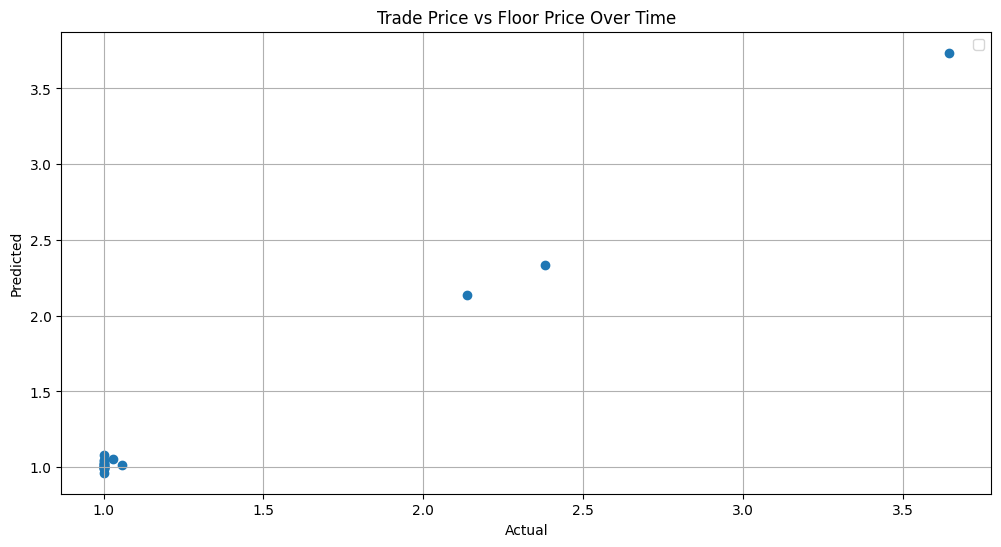

In [6]:
plt.figure(figsize=(12, 6), dpi=100)
plt.scatter(results['Actual'], results['Predicted'])
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Trade Price vs Floor Price Over Time')
plt.legend()
plt.grid(True)